In [6]:
import pandas as pd
def load_prepare_data(path):
  """
  Función para cargar y procesar datos para el ejercicio.
  """
  df = pd.read_csv(path,sep=",")
  map_classes = {
    "religion":1,
    "age":1,
    "ethnicity":1,
    "gender":1,
    "other_cyberbullying":1,
    "not_cyberbullying":0,
  }
  df["cyberbullying"] = df.cyberbullying_type.map(map_classes)
  return df[["tweet_text","cyberbullying"]].copy()

# Ejercicio


En este ejercicio vamos a trabajar con un conjunto de datos procedente de medios sociales online.

Uno de los mayores problemas en el internet de hoy en día es la presencia de actitudes negativas hacia algunos colectivos en relación a su etnia, género, religión o ideología política. En este ejercicio trabajaremos con un conjunto de datos reales, etiquetados manualmente, procedentes de la plataforma [Kaggle](https://www.kaggle.com/datasets/andrewmvd/cyberbullying-classification/data). Originalmente, a cada documento del dataset se le asignó una de las siguientes categorías:
- *religion*
- *age*
- *ethnicity*
- *gender*
- *other_cyberbullying*
- *not_cyberbullying*


El objetivo inicial del dataset era su uso para entrenar un modelo capaz de detectar el tipo de contenido de odio presente en internet según el colectivo al que se atacaba. En este caso, para simplificar el ejercicio, se ha generado una función `load_prepare_data()` que cambia las categorías del dataset obteníendose al final 2 categorías con valor 1 o 0, indicando si el tweet tiene contenido de odio

Para el ejercicio debéis entrenar diferentes modelos de clasificación que permitan clasificar correctamente los tweets. Para ello será necesario crear y utilizar funciones de preprocesado de datos similares a las vistas en clase, aplicar estrategias de vectorización de trextos como TF-IDF o embeddings, y entrenar/evaluar modelos de clasificación. Para que os sirva de orientación, los criterios de evaluación del ejercicio serán los siguientes:

-	**Análisis exploratorio, pre-procesado y normalización de los datos (30%)**:
        -	El ejercicio deberá contener un análisis exploratorio de los datos como número de documentos, gráficas de distribución de longitudes y/o wordclouds, entre otros análisis que se os pudieran ocurrir. Vuestros ejercicios deberán incorporar al menos los análisis exploratorios vistos en clase.

    -	También tendréis que tener funciones para normalizar textos que permitan eliminar palabras vacías, quitar símbolos de puntuación y lematizar o hacer stemming.  

-	**Vectorización de textos (40%)**

    En clase hemos visto diferentes estrategias de vectorización como TF-IDF y Word Embeddings. Será necesario incorporar características adicionales como el sentimiento o características léxicas.

-	**Entrenamiento y validación del sistema (30%)**
  -	En el proceso de entrenamiento del modelo tendréis que testear al menos 3 modelos de clasificación. El procedimiento debe ser similar al visto en clase, en el que primero estimábamos el rendimiento de varios algoritmos de forma general, para posteriormente seleccionar el mejor para ajustar los hiperparámetros.


**Nota 1**: El ejercicio propuesto es similar a los ejercicios de clasificación visto en clase, por lo que es importante que documentéis y expliquéis adecuadamente (con vuestras palabras) los procesos llevados a cabo en el ejercicio. No hacerlo puede llegar a penalizar hasta 1 punto en la calificación final.

**Nota 2**: Cualquier cálculo adicional a los vistos en clase (visualizaciones, nuevas características añadidas al modelo...) será valorado positivamente en la calificación.

## 0. Imports and Auxiliary functions


### Imports

In [7]:
import pandas as pd
import numpy as np

## Plot
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

## Natural Language Processing
import nltk
nltk.download('stopwords')
nltk.download('punkt')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.tokenize import sent_tokenize
from nltk.tokenize import TweetTokenizer
from nltk.util import ngrams
from nltk import FreqDist

## Vectorizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

## Model selection
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

## Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

## Metrics
from sklearn.metrics import f1_score, confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score
from sklearn.metrics import ConfusionMatrixDisplay

## Resample
from sklearn.utils import resample
from imblearn.over_sampling import SMOTE

from tqdm.autonotebook import tqdm
tqdm.pandas()

import sys
!{sys.executable} -m pip install contractions
import contractions

import spacy
import scipy as sp

import warnings

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


## Auxiliary Functions

In [8]:
# Function to get the top n grams that we pass as paramater
def getTopNGrams(corpus, nGram, top):
    countVectorizer = CountVectorizer(ngram_range = nGram, stop_words = 'english').fit(corpus)
    bagWords = countVectorizer.transform(corpus)
    wordFrequency = bagWords.sum(axis = 0)
    print(wordFrequency)
    wordFrequency = [(word, wordFrequency[0, idx]) for word, idx in countVectorizer.vocabulary_.items()]
    wordFrequency = sorted(wordFrequency, key = lambda x: x[1], reverse=True)
    return wordFrequency[:top]


## Transform and Normalization Functions

# Remove blank spaces
def removeBlankSpaces(text):
    return  " ".join(text.split())

# To lowercase
def textToLowerCase(text):
  return text.lower()

# Replace contractions
def replaceContraction(text):
    return contractions.fix(text, slang=True)

tweet_tokenizer = TweetTokenizer()
def normalizeTokens(document):
    # Divide the document in words
    words =  tweet_tokenizer.tokenize(document)

    # Replace URLs, Twitter mentions, numbers, and retweets by the token as following
    for i in range(len(words)):
        if words[i].startswith("http://") or words[i].startswith("https://") or words[i].startswith("www."):
            words[i] = "URL"
        elif words[i].startswith("@"):
            words[i] = "MENTION"
        elif words[i].startswith("rt"):
            words[i] = "RETWEET"
        elif words[i].isdigit():
            words[i] = "NUM"

    # Join the words in a new modified document
    modifiedDocument = ' '.join(words)

    return modifiedDocument

nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])
def lemmatizeTokens(text):
    # Processing the text with the nlp object
    doc = nlp(text)

    # Lemmatize the text
    lemas = [token.lemma_ for token in doc]

    # Remove stopwords
    filteredTokens = [token for token in lemas if token.isalpha() and token.lower() not in en_stopwords]

    # Join the filtered tokens in a new text
    processedText = ' '.join(filteredTokens)

    return processedText

# Function to evaluate the model
def model_evaluation(models, score, X, y):
      results = []
      names = []
      # For each model
      for name, model in models:
          warnings.filterwarnings('ignore')

          # StratifiedKFold
          KF = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 98)

          #  Croos_val
          cv_results = cross_val_score(model, X, y, cv = KF, scoring = score, verbose = False)

          # Saving results
          results.append(cv_results)
          names.append(name)

          # Show results
          print('Metric: {} , KFold '.format(str(score)))
          print("%s: %f (%f) " % (name, cv_results.mean(), cv_results.std()))

      return results, names

## 1. Getting the Corpus
To obtain the data we have the function `load_prepare_data()`. This function prepare the data in a dataframe with Pandas format.

In [9]:
path_data = "https://raw.githubusercontent.com/luisgasco/ntic_master_datos/main/datasets/cyberbullying_tweets.csv"
# Path de datos alternativos en caso de que el anterior no funcione (al estar alojado en github puede haber limitaciones
# en la descarga.
# path_data = "https://zenodo.org/records/10938455/files/cyberbullying_tweets.csv?download=1"
dataset = load_prepare_data(path_data)

In [10]:
dataset.head(4)

,tweet_text,cyberbullying
0,"In other words #katandandre, your food was cra...",0
1,Why is #aussietv so white? #MKR #theblock #ImA...,0
2,@XochitlSuckkks a classy whore? Or more red ve...,0
3,"@Jason_Gio meh. :P thanks for the heads up, b...",0


## 2. Exploratory analysis

* **Number of documents and columns**



In [11]:
dataset.shape

(47692, 2)

Our dataset has 47692 documents and 2 columns

* **Number of duplicated documents and nulls**



In [12]:
print(np.sum(dataset.duplicated(subset=["tweet_text"])))

1675


We found 1675 duplicated documents, so we are gonna proceed to delete them

In [13]:
dataset = dataset.drop_duplicates(subset=["tweet_text"])
dataset.shape[0]

46017

In [14]:
print("There are {} empty tweets and {} empty values in the cyberbullying labels".format(np.sum(dataset.isnull())[0], np.sum(dataset.isnull())[1]))

There are 0 empty tweets and 0 empty values in the cyberbullying labels


/usr/local/lib/python3.10/dist-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)
<ipython-input-14-009aa311d8d2>:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print("There are {} empty tweets and {} empty values in the cyberbullying labels".format(np.sum(dataset.isnull())[0], np.sum(dataset.isnull())[1]))


* **Number of documents by cyberbullying class**


Let's going to analise how if our column 'cyberbullying' is equally distributed and how many documents, of each type, we have.

In [15]:
dataset['cyberbullying'].value_counts()

,count
cyberbullying,
1,38080
0,7937


We can observe that our column has two different values:

* Cyberbullying = 1: Means, tweets with cyberbullying identified according to the words in them.

* Cyberbullying = 0: Means, on the other hand, tweets without cyberbullying content.

We can see as well, that our column is not equally distributed, is imbalanced. However, first, we are going to study it and create a model without making applying techniques to overcome problems caused by imbalanced datasets.

At the end, we are going to try to handle the imbalanced dataset and compare the result.

* **Tweet distribution by lenght of characters**


In [16]:
dataset["char_len"] = dataset["tweet_text"].apply(lambda x: len(x))

<Figure size 1400x1200 with 0 Axes>

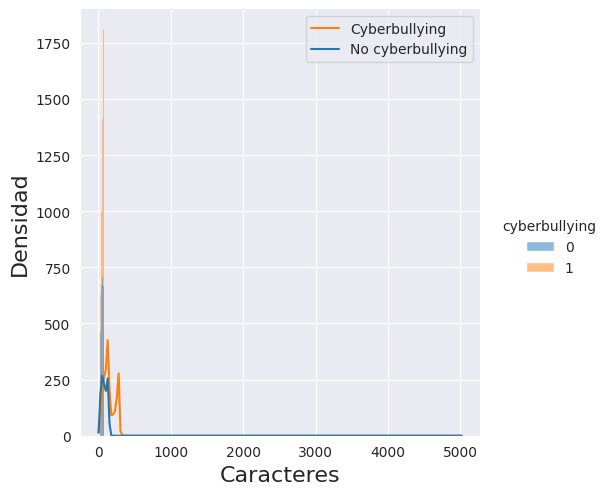

In [17]:
fig = plt.figure(figsize=(14,12))
sns.set_style("darkgrid")

sns.displot(data=dataset, x="char_len", hue="cyberbullying", kde=True, legend=True, bins=[20, 30, 40, 50, 60, 70])

plt.legend(["Cyberbullying", "No cyberbullying"])

# Axis title
plt.xlabel('Caracteres', fontsize=16)
plt.ylabel('Densidad', fontsize=16)

plt.show()

* **Content analysis**

In [18]:
text_no_cyberbullying = ",".join(dataset[dataset.cyberbullying==0].tweet_text.to_list())
text_cyberbullying = ",".join(dataset[dataset.cyberbullying==1].tweet_text.to_list())

In [19]:
en_stopwords = stopwords.words('english')
from PIL import Image
custom_mask = np.array(Image.open('/content/sample_data/twitterMask.png'))
wordcloud = WordCloud(background_color="white",
                      mask = custom_mask,
                      max_words=5000,
                      contour_width=0,
                      contour_color='steelblue',
                      stopwords=en_stopwords,
                      normalize_plurals = True)

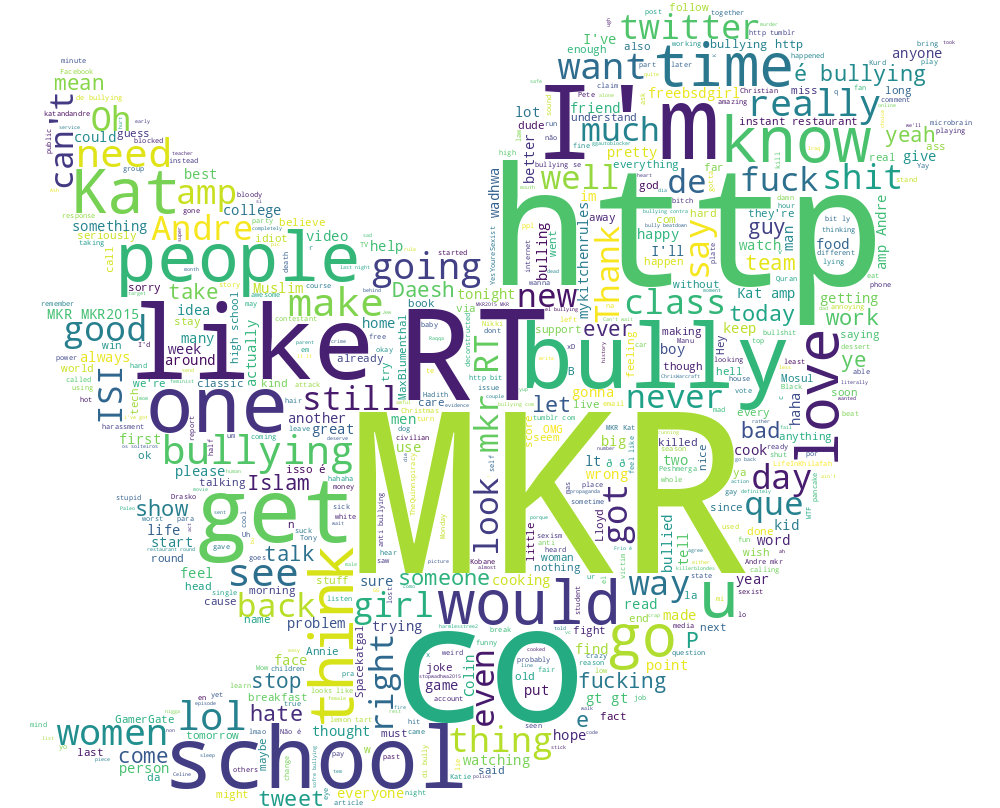

In [20]:
# Generate the wordcloud and show
wordcloud.generate(text_no_cyberbullying)
wordcloud.to_image()

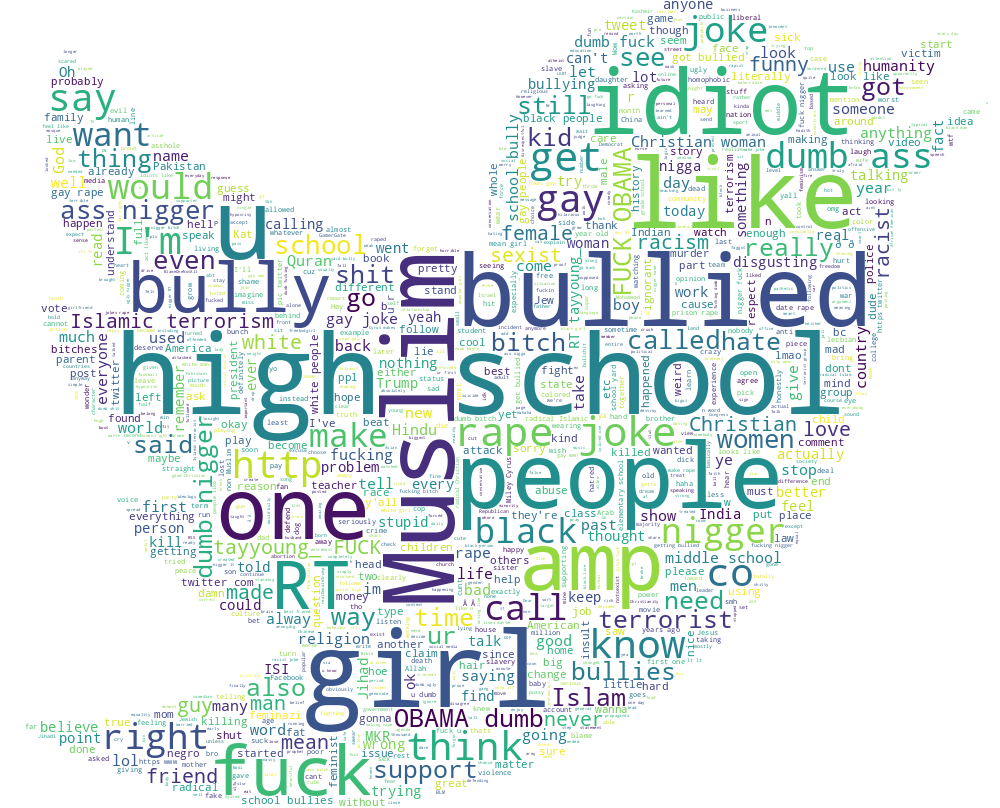

In [21]:
# Generate the wordcloud and show
wordcloud.generate(text_cyberbullying)
wordcloud.to_image()

On the wordcloud with 'cyberbullying = 0' we can observe a huge number of URL's, retweet, likes, etc. We can't see as many adjectives to express opinion as in the second, where the cybebullying was detected.

In that case, we can see 'high school', place where is very common to find cases of bullying, references to religion such as 'muslim' or racist terms to call black people.

Now, we are gonna get the gram more common in out dataset.

In [22]:
tweet_text = dataset['tweet_text'].to_list()
unigrams = getTopNGrams(tweet_text,(1,1),10)
bigrams = getTopNGrams(tweet_text,(2,2),10)
trigrams = getTopNGrams(tweet_text,(3,3),10)

[[16 65  1 ...  1  1  1]]
[[1 1 1 ... 1 1 1]]
[[1 1 1 ... 1 1 1]]


We are gonna study the most common unigrams

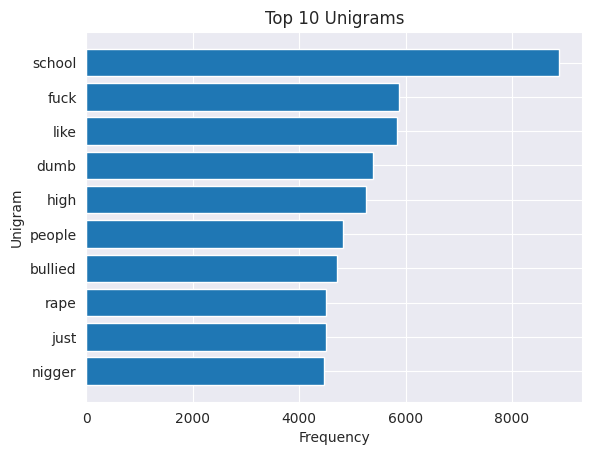

In [23]:
topTenUnigrams = pd.DataFrame(unigrams, columns = ['text', 'frequency'])
topTenUnigramsSorted = topTenUnigrams.sort_values('frequency', ascending = True)

plt.barh(topTenUnigramsSorted.text, topTenUnigramsSorted.frequency)
# setting label of y-axis
plt.ylabel("Unigram")

# setting label of x-axis
plt.xlabel("Frequency")
plt.title("Top 10 Unigrams")
plt.show()

We are gonna study the most common bigrams

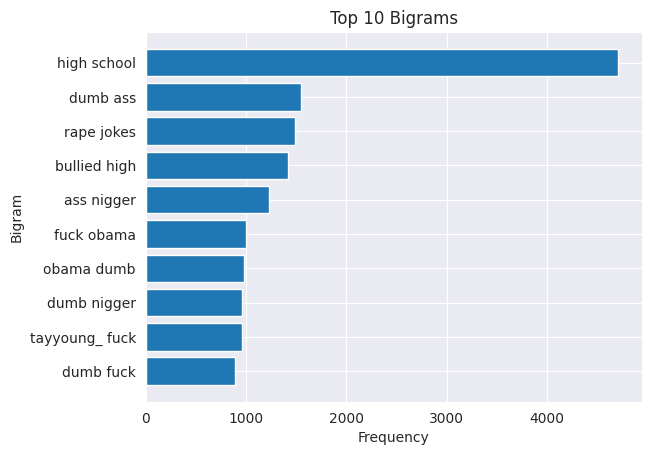

In [24]:
topTenBigrams = pd.DataFrame(bigrams, columns = ['text', 'frequency'])
topTenBigramsSorted = topTenBigrams.sort_values('frequency', ascending = True)

plt.barh(topTenBigramsSorted.text, topTenBigramsSorted.frequency)
# setting label of y-axis
plt.ylabel("Bigram")

# setting label of x-axis
plt.xlabel("Frequency")
plt.title("Top 10 Bigrams")
plt.show()


We are gonna study the most common trigrams

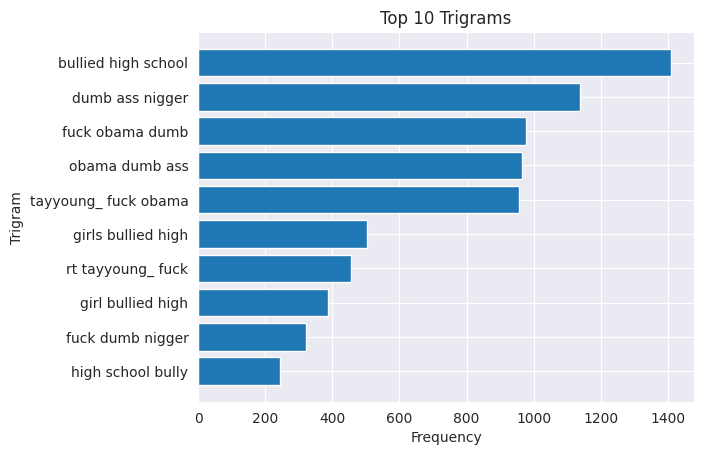

In [25]:
topTenTrigrams = pd.DataFrame(trigrams, columns = ['text', 'frequency'])
topTenTrigramsSorted = topTenTrigrams.sort_values('frequency', ascending = True)

plt.barh(topTenTrigramsSorted.text, topTenTrigramsSorted.frequency)
# setting label of y-axis
plt.ylabel("Trigram")

# setting label of x-axis
plt.xlabel("Frequency")
plt.title("Top 10 Trigrams")
plt.show()

## 3. Preprocessing and normalization

In [26]:
# Remove blank spaces and converting the text to lowercase
dataset["normalized"] = dataset["tweet_text"].progress_apply(lambda x: removeBlankSpaces(x))
dataset["normalized"] = dataset["normalized"].progress_apply(lambda x: textToLowerCase(x))

  0%|          | 0/46017 [00:00<?, ?it/s]

  0%|          | 0/46017 [00:00<?, ?it/s]

In [27]:
# Replace contractions
dataset["normalized"] = dataset["normalized"].progress_apply(lambda x: replaceContraction(x))

  0%|          | 0/46017 [00:00<?, ?it/s]

In [28]:
# Replace URLs, Twitter mentions, numbers, and retweets
dataset["normalized"] = dataset["normalized"].progress_apply(lambda x: normalizeTokens(x))

  0%|          | 0/46017 [00:00<?, ?it/s]

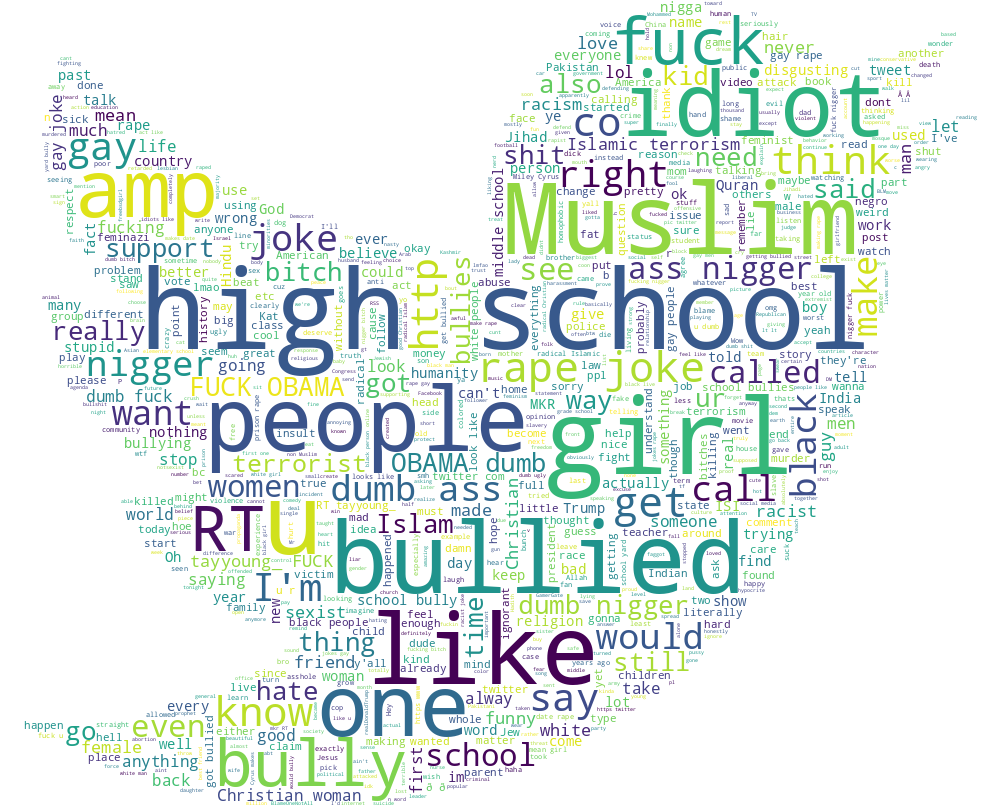

In [29]:
# Generate and show the wordcloud
wordcloud.generate(text_cyberbullying)
wordcloud.to_image()

In [30]:
dataset["preprocessed_text"] = dataset["normalized"].progress_apply(lambda x: lemmatizeTokens(x))

  0%|          | 0/46017 [00:00<?, ?it/s]

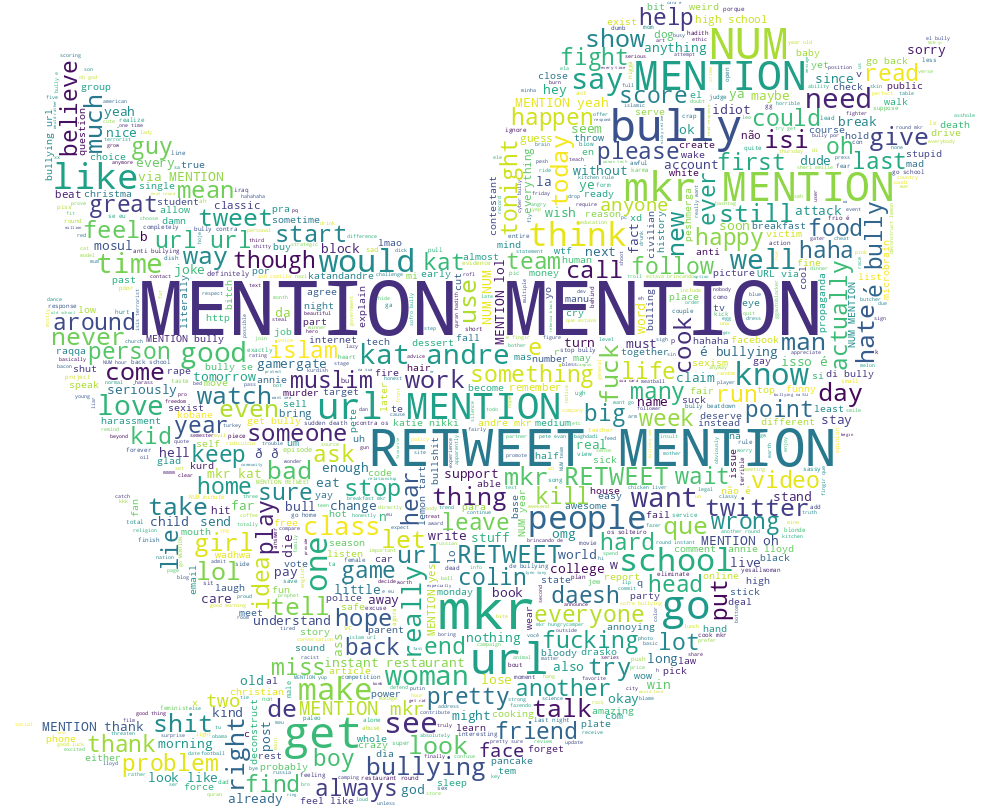

In [31]:
txt_cat0 = ",".join(dataset[dataset.cyberbullying==0].preprocessed_text.to_list())
txt_cat1 = ",".join(dataset[dataset.cyberbullying==1].preprocessed_text.to_list())

# Generate and show the wordcloud
wordcloud.generate(txt_cat0)
wordcloud.to_image()

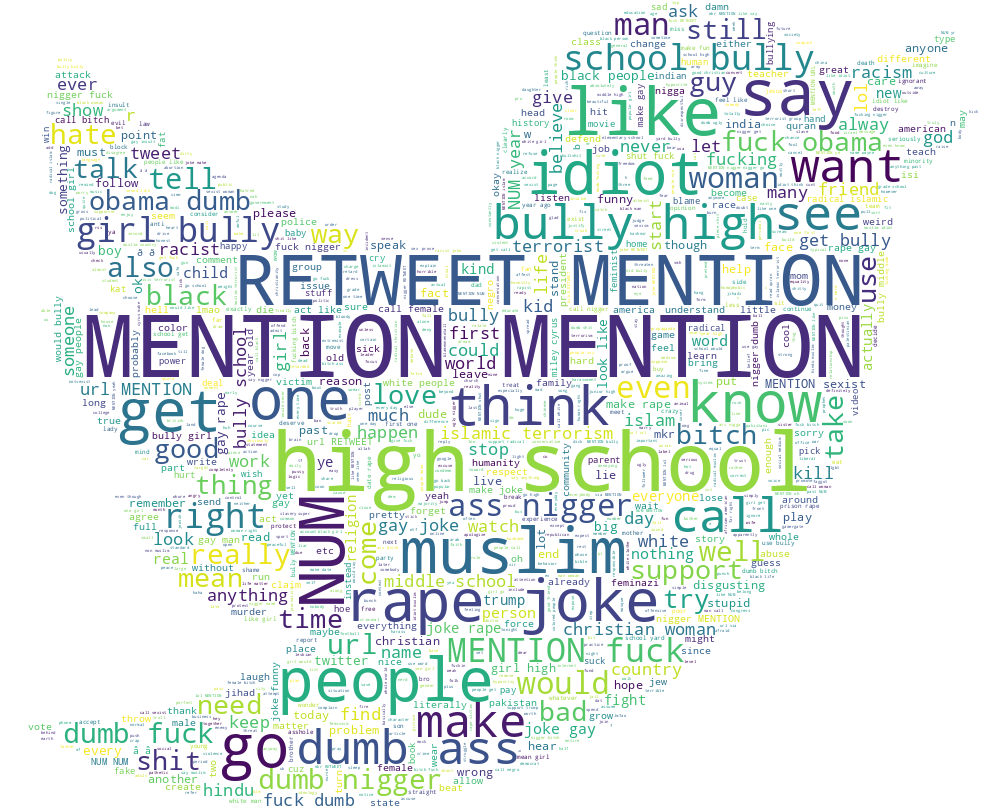

In [32]:
# Generate and show the wordcloud
wordcloud.generate(txt_cat1)
wordcloud.to_image()

In [33]:
def token_appearance(document, token = "MENTION"):
  return len([x for x in document.split() if x == token])

dataset["num_mention"] = dataset["preprocessed_text"].progress_apply(lambda x: token_appearance(x, token="MENTION"))
dataset["num_URLS"] = dataset["preprocessed_text"].progress_apply(lambda x: token_appearance(x, token="URL"))
dataset["num_NUM"] = dataset["preprocessed_text"].progress_apply(lambda x: token_appearance(x, token="NUM"))
dataset["num_rt"] = dataset["preprocessed_text"].progress_apply(lambda x: token_appearance(x, token="RETWEET"))

  0%|          | 0/46017 [00:00<?, ?it/s]

  0%|          | 0/46017 [00:00<?, ?it/s]

  0%|          | 0/46017 [00:00<?, ?it/s]

  0%|          | 0/46017 [00:00<?, ?it/s]

In [34]:
dataset

,tweet_text,cyberbullying,char_len,normalized,preprocessed_text,num_mention,num_URLS,num_NUM,num_rt
0,"In other words #katandandre, your food was cra...",0,61,"in other words #katandandre , your food was cr...",word katandandre food crapilicious mkr,0,0,0,0
1,Why is #aussietv so white? #MKR #theblock #ImA...,0,115,why is #aussietv so white ? #mkr #theblock #im...,aussietv white mkr theblock imacelebrityau tod...,0,0,0,0
2,@XochitlSuckkks a classy whore? Or more red ve...,0,60,MENTION a classy whore ? or more red velvet cu...,MENTION classy whore red velvet cupcake,1,0,0,0
3,"@Jason_Gio meh. :P thanks for the heads up, b...",0,103,"MENTION meh . :p thanks for the heads up , but...",MENTION meh thank head concerned another angry...,1,0,0,0
4,@RudhoeEnglish This is an ISIS account pretend...,0,103,MENTION this is an isis account pretending to ...,MENTION isis account pretend kurdish account l...,1,0,0,0
...,...,...,...,...,...,...,...,...,...
47687,"Black ppl aren't expected to do anything, depe...",1,234,"black people are not expected to do anything ,...",black people expect anything depend anything y...,0,0,0,0
47688,Turner did not withhold his disappointment. Tu...,1,276,turner did not withhold his disappointment . t...,turner withhold disappointment turner call cou...,0,0,0,0
47689,I swear to God. This dumb nigger bitch. I have...,1,104,i swear to god . this dumb nigger bitch . i ha...,swear god dumb nigger bitch get bleach hair re...,0,0,0,0
47690,Yea fuck you RT @therealexel: IF YOURE A NIGGE...,1,90,yea fuck you RETWEET MENTION : if you are a ni...,yea fuck RETWEET MENTION nigger fucking unfoll...,1,0,0,1


## 4. Vectorization

* Limitar el tamaño de características del vector que representa el documento
* Considerar unigramas, bigramas y trigramas
* Que el sistema no considere los elementos que salgan en menos del 0.5% de los documentos.

In [35]:
vectorizer = TfidfVectorizer(lowercase = False, stop_words =None,
                               min_df=0.005, ngram_range = (1,3))

dataVector = vectorizer.fit_transform(dataset["preprocessed_text"])

In [36]:
dataVector

<46017x409 sparse matrix of type '<class 'numpy.float64'>'
	with 382368 stored elements in Compressed Sparse Row format>

In [37]:
extra_features = dataset[['num_mention','num_URLS','num_NUM', 'num_rt']]

In [38]:
# we get the target and assign to a variable
y = dataset["cyberbullying"].values.astype(np.float32)

# Join the TFDIF with the new characteristics calculated
# extra_features extraction
X = sp.sparse.hstack((dataVector,extra_features.values),format='csr')

In [39]:
X_columns=list(vectorizer.get_feature_names_out())+extra_features.columns.tolist()

## 5. Models training and evaluation


In [40]:
X

<46017x413 sparse matrix of type '<class 'numpy.float64'>'
	with 408358 stored elements in Compressed Sparse Row format>

In [41]:
# Split the resampled data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

We saw at the beginning, on the exploratory analysis, that our dataset was not balanced. So, we are gonna study, create, training and evaluate models in 2 diferent scenarios:

*   Doing oversampling to solve that unbalancement
*   Studying our original unbalanced dataset

At the end, according our results, we are gonna decide which strategy to take in this case.

### With Oversampling

In [42]:
# Doing oversampling with SMOTE
smote = SMOTE()
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [43]:
# Models definition
models = [
         ("Logistic",LogisticRegression(random_state=30)),
         ("GaussianNB",GaussianNB()),
         ("RandomForest", RandomForestClassifier()),
         ("DecissionTree", DecisionTreeClassifier())
]

evaluation_score = "accuracy"

model_evaluation(models, evaluation_score, X_train_resampled.toarray(), y_train_resampled)

Metric: accuracy , KFold 
Logistic: 0.874287 (0.003460) 
Metric: accuracy , KFold 
GaussianNB: 0.805007 (0.002832) 
Metric: accuracy , KFold 
RandomForest: 0.918546 (0.001852) 
Metric: accuracy , KFold 
DecissionTree: 0.892410 (0.003030) 


([array([0.87375061, 0.8807144 , 0.87325905, 0.87021712, 0.87349447]),
  array([0.80329346, 0.80902835, 0.80534164, 0.8007374 , 0.80663662]),
  array([0.9169261 , 0.92143208, 0.91913813, 0.91618189, 0.91904957]),
  array([0.89029985, 0.89734557, 0.89431427, 0.8911102 , 0.88897993])],
 ['Logistic', 'GaussianNB', 'RandomForest', 'DecissionTree'])

We are gonna to tune up the hyperparameters

In [44]:
# Define model and parameters
stratified_kfold = StratifiedKFold(n_splits = 5,
                                   shuffle = True,
                                   random_state = 11)
model = RandomForestClassifier()
grid_param = {
        'criterion': ['gini', 'entropy'],
        'max_features': ['auto', 'sqrt', 'log2'],
        'max_depth': [16,20,22,24],
        'n_estimators': [100, 200, 300]
}

In [45]:
model_grid = RandomizedSearchCV(model,
                                param_distributions=grid_param,
                                n_iter=5,
                                scoring='accuracy',
                                n_jobs=4,
                                cv=stratified_kfold,
                                random_state=42 )

In [46]:
grid_result = model_grid.fit(X_train_resampled, y_train_resampled)
# summarize results
print("Best accuracy: %f using the parameters %s" % (grid_result.best_score_, grid_result.best_params_))

Best accuracy: 0.868798 using the parameters {'n_estimators': 300, 'max_features': 'log2', 'max_depth': 22, 'criterion': 'entropy'}


In [47]:
rf = RandomForestClassifier(criterion='entropy',
                            n_estimators = 300,
                            max_features = 'log2',
                            max_depth = 22,
                            random_state=42,
                            n_jobs=-1)

rf.fit(X_train_resampled, y_train_resampled)

RandomForestClassifier(criterion='entropy', max_depth=22, max_features='log2',
                       n_estimators=300, n_jobs=-1, random_state=42)

In [48]:
y_pred = rf.predict(X_test)

print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[1567   71]
 [1861 5705]]
              precision    recall  f1-score   support

         0.0       0.46      0.96      0.62      1638
         1.0       0.99      0.75      0.86      7566

    accuracy                           0.79      9204
   macro avg       0.72      0.86      0.74      9204
weighted avg       0.89      0.79      0.81      9204



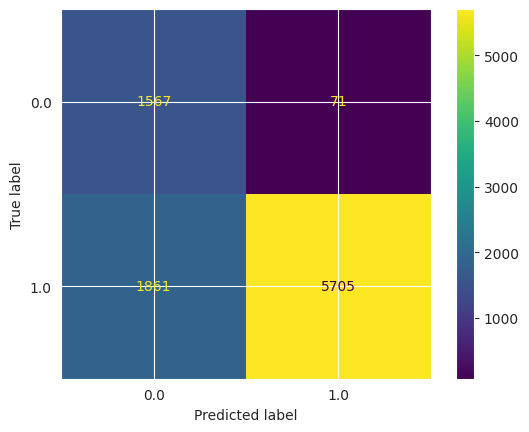

In [49]:
ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test, normalize = None)

We can see that, doing the oversampling, the precision to detect the absence of cyberbullying is just the 46%. However we can identify a case of cyberbullying with a 99% of precision.

In [50]:
# Get the variables more important for our model
importance = rf.feature_importances_

# First, we match the features' name and importance
features_importances = list(zip(X_columns, importance))

# DESC sort
features_importances_sorted = sorted(features_importances, key=lambda x: x[1], reverse=True)
X_columns_sorted, importance_sorted = zip(*features_importances_sorted)

Feature: 0, Name: mkr, Score: 0.05119
Feature: 1, Name: nigger, Score: 0.04107
Feature: 2, Name: MENTION, Score: 0.03823
Feature: 3, Name: rape, Score: 0.03553
Feature: 4, Name: dumb, Score: 0.03533
Feature: 5, Name: idiot, Score: 0.03156
Feature: 6, Name: school, Score: 0.03003
Feature: 7, Name: gay, Score: 0.02978
Feature: 8, Name: muslim, Score: 0.02927
Feature: 9, Name: high, Score: 0.02898
Feature: 10, Name: okay, Score: 0.00006
Feature: 11, Name: social, Score: 0.00006
Feature: 12, Name: bring, Score: 0.00006
Feature: 13, Name: mind, Score: 0.00005
Feature: 14, Name: fat, Score: 0.00005
Feature: 15, Name: weird, Score: 0.00005
Feature: 16, Name: agree, Score: 0.00005
Feature: 17, Name: police, Score: 0.00005
Feature: 18, Name: shame, Score: 0.00005
Feature: 19, Name: sound, Score: 0.00004


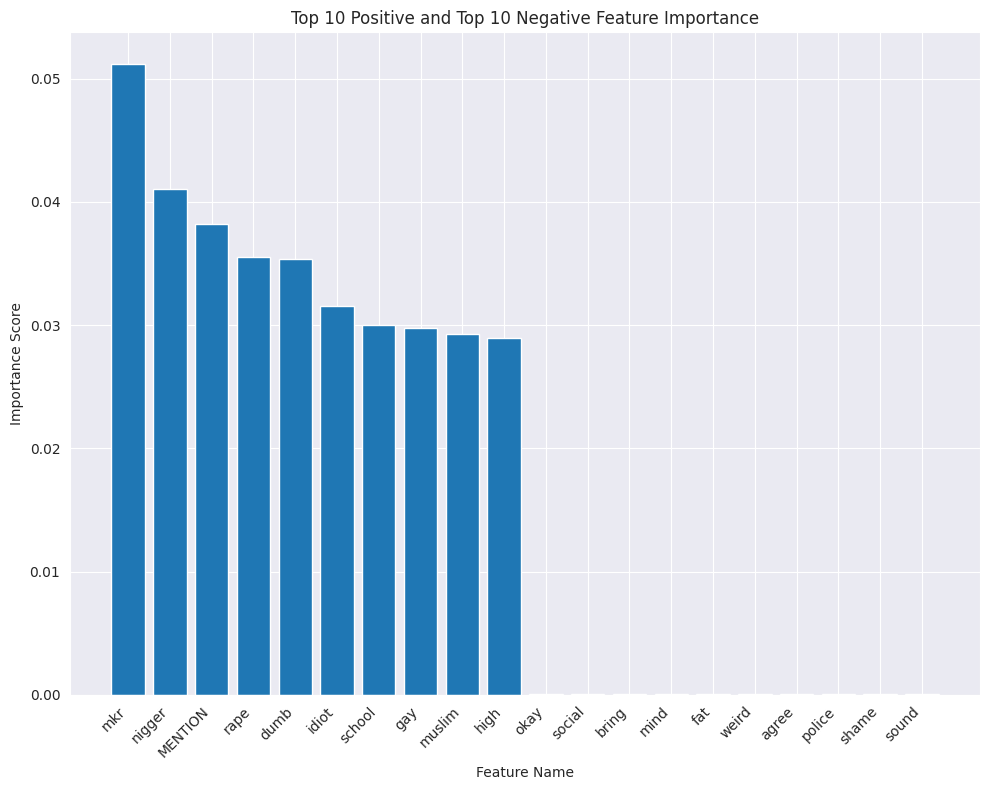

In [51]:
# Select top10 positive and top10 negative features
top_features = X_columns_sorted[:10] + X_columns_sorted[-10:]
top_importance = importance_sorted[:10] + importance_sorted[-10:]

# Show feature's name, number and importance score
for i, (feature, importance) in enumerate(zip(top_features, top_importance)):
    print('Feature: %0d, Name: %s, Score: %.5f' % (i, feature, importance))

# Plot
plt.figure(figsize=(10, 8))
plt.bar(top_features, top_importance)

plt.xticks(rotation=45, ha="right")
plt.xlabel('Feature Name')
plt.ylabel('Importance Score')
plt.title('Top 10 Positive and Top 10 Negative Feature Importance')
plt.tight_layout()

plt.show()

### Without Oversampling

We are proceed in the same way, but without balance our original dataset

In [52]:
# Models definition
models = [
         ("Logistic",LogisticRegression(random_state=30)),
         ("GaussianNB",GaussianNB()),
         ("RandomForest", RandomForestClassifier()),
         ("DecissionTree", DecisionTreeClassifier())
]

evaluation_score = "accuracy"

model_evaluation(models, evaluation_score, X_train.toarray(), y_train)

Metric: accuracy , KFold 
Logistic: 0.860593 (0.004243) 
Metric: accuracy , KFold 
GaussianNB: 0.617065 (0.004976) 
Metric: accuracy , KFold 
RandomForest: 0.869476 (0.003613) 
Metric: accuracy , KFold 
DecissionTree: 0.848423 (0.003773) 


([array([0.86622301, 0.86106207, 0.85304903, 0.86158653, 0.86104319]),
  array([0.61075649, 0.62284395, 0.61727557, 0.61219777, 0.62224939]),
  array([0.87342116, 0.86934673, 0.86309928, 0.86905732, 0.87245314]),
  array([0.85386391, 0.84829553, 0.84544343, 0.84338495, 0.85112741])],
 ['Logistic', 'GaussianNB', 'RandomForest', 'DecissionTree'])

In [53]:
# Define model and parameters
stratified_kfold = StratifiedKFold(n_splits = 5,
                                   shuffle = True,
                                   random_state = 11)
model = RandomForestClassifier()
grid_param = {
        'criterion': ['gini', 'entropy'],
        'max_features': ['auto', 'sqrt', 'log2'],
        'max_depth': [16,20,22,24],
        'n_estimators': [100, 200, 300]
}

In [54]:
model_grid = RandomizedSearchCV(model,
                                param_distributions=grid_param,
                                n_iter=5,
                                scoring='accuracy',
                                n_jobs=4,
                                cv=stratified_kfold,
                                random_state=42 )

In [55]:
grid_result = model_grid.fit(X_train, y_train)
# summarize results
print("Mejor accuracy: %f usando los parámetros %s" % (grid_result.best_score_, grid_result.best_params_))

Mejor accuracy: 0.852905 usando los parámetros {'n_estimators': 200, 'max_features': 'sqrt', 'max_depth': 16, 'criterion': 'gini'}


In [57]:
rf = RandomForestClassifier(criterion='gini',
                            n_estimators = 200,
                            max_features = 'sqrt',
                            max_depth = 16,
                            random_state=42,
                            n_jobs=-1)

rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=16, n_estimators=200, n_jobs=-1,
                       random_state=42)

In [58]:
y_pred = rf.predict(X_test)

print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[ 270 1368]
 [  57 7509]]
              precision    recall  f1-score   support

         0.0       0.83      0.16      0.27      1638
         1.0       0.85      0.99      0.91      7566

    accuracy                           0.85      9204
   macro avg       0.84      0.58      0.59      9204
weighted avg       0.84      0.85      0.80      9204



In this case, we can predict, with more than 80% of precision, if a tweet content has cyberbullying or not. So, we have a more balanced the precision in both categories, if we have the dataset without the oversampling done.

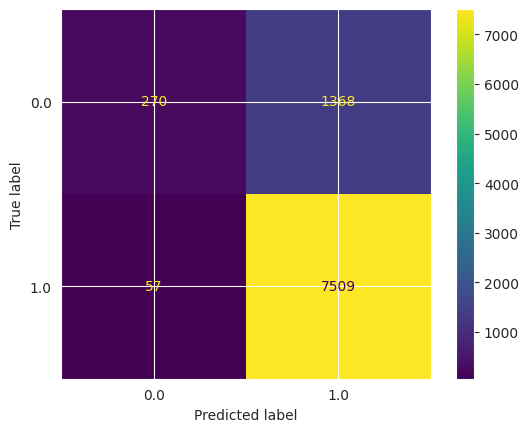

In [59]:
ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test, normalize = None)

In [60]:
# Get the variables more important for our model
importance = rf.feature_importances_

# First, we match the features' name and importance
features_importances = list(zip(X_columns, importance))

# DESC sort
features_importances_sorted = sorted(features_importances, key=lambda x: x[1], reverse=True)
X_columns_sorted, importance_sorted = zip(*features_importances_sorted)

Feature: 0, Name: mkr, Score: 0.13270
Feature: 1, Name: MENTION, Score: 0.04792
Feature: 2, Name: bully, Score: 0.04202
Feature: 3, Name: bullying, Score: 0.03925
Feature: 4, Name: school, Score: 0.03791
Feature: 5, Name: nigger, Score: 0.03703
Feature: 6, Name: fuck, Score: 0.03040
Feature: 7, Name: rape, Score: 0.02926
Feature: 8, Name: muslim, Score: 0.02861
Feature: 9, Name: idiot, Score: 0.02695
Feature: 10, Name: comment, Score: 0.00002
Feature: 11, Name: america, Score: 0.00002
Feature: 12, Name: dick, Score: 0.00002
Feature: 13, Name: bully girl, Score: 0.00001
Feature: 14, Name: make rape, Score: 0.00001
Feature: 15, Name: gay people, Score: 0.00000
Feature: 16, Name: bully middle, Score: 0.00000
Feature: 17, Name: nigger dumb, Score: 0.00000
Feature: 18, Name: rape joke gay, Score: 0.00000
Feature: 19, Name: make joke, Score: 0.00000


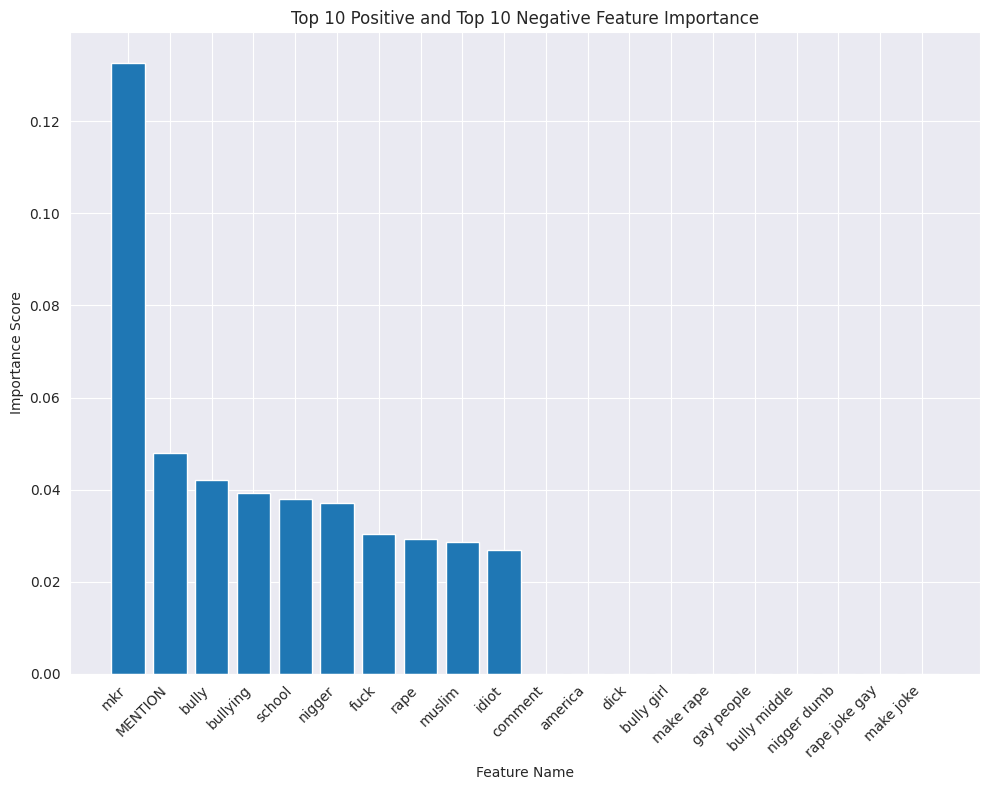

In [61]:
# Select top10 positive and top10 negative features
top_features = X_columns_sorted[:10] + X_columns_sorted[-10:]
top_importance = importance_sorted[:10] + importance_sorted[-10:]

# Show feature's name, number and importance score
for i, (feature, importance) in enumerate(zip(top_features, top_importance)):
    print('Feature: %0d, Name: %s, Score: %.5f' % (i, feature, importance))

# Plot
plt.figure(figsize=(10, 8))
plt.bar(top_features, top_importance)

plt.xticks(rotation=45, ha="right")
plt.xlabel('Feature Name')
plt.ylabel('Importance Score')
plt.title('Top 10 Positive and Top 10 Negative Feature Importance')
plt.tight_layout()
plt.show()

## 6. Final conclusions

Regarding which model to use and, if we do oversampling or not, we can conclude:

It's true that we have a better score, in average, without the oversampling, (in both categories we got for precision more than 80%), however, how I understand the context is that both categories are self-exclusive. I mean, a tweet has two possible states, with or without cyberbullying. So, knowing if a tweet belongs to one category, we can discard the other.

Then, if doing the oversampling, we have a precision to detect cyberbullying with a 99% in a tweet, I would take that model, because we can predict, with almost a perfect accuracy, the cyberbullying on it.